In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("phishing.csv")

df.shape
df.head()

Saving phishing.csv to phishing.csv


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [ ]:
df.info()
df.describe()
df["class"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

,count
class,
1,6157
-1,4897


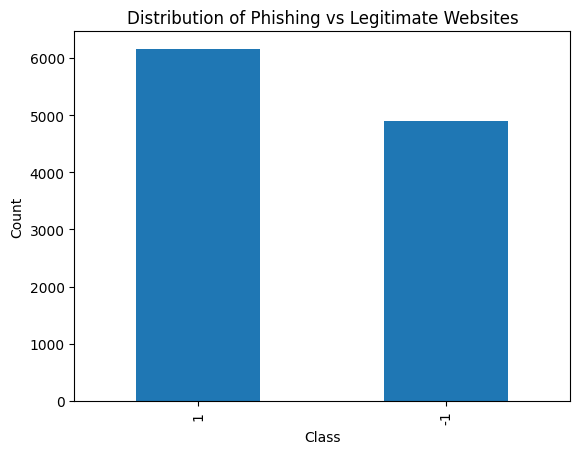

In [ ]:
df["class"].value_counts().plot(kind="bar")
plt.title("Distribution of Phishing vs Legitimate Websites")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

This figure shows the distrubition between real and phishing websites within our dataset. Our dataset appears to be relatively balanced, but has a slightly higher number of legit samples compared to phishing samples. This type of balance is good for supervised learning models, as it reduces the risk of bias.

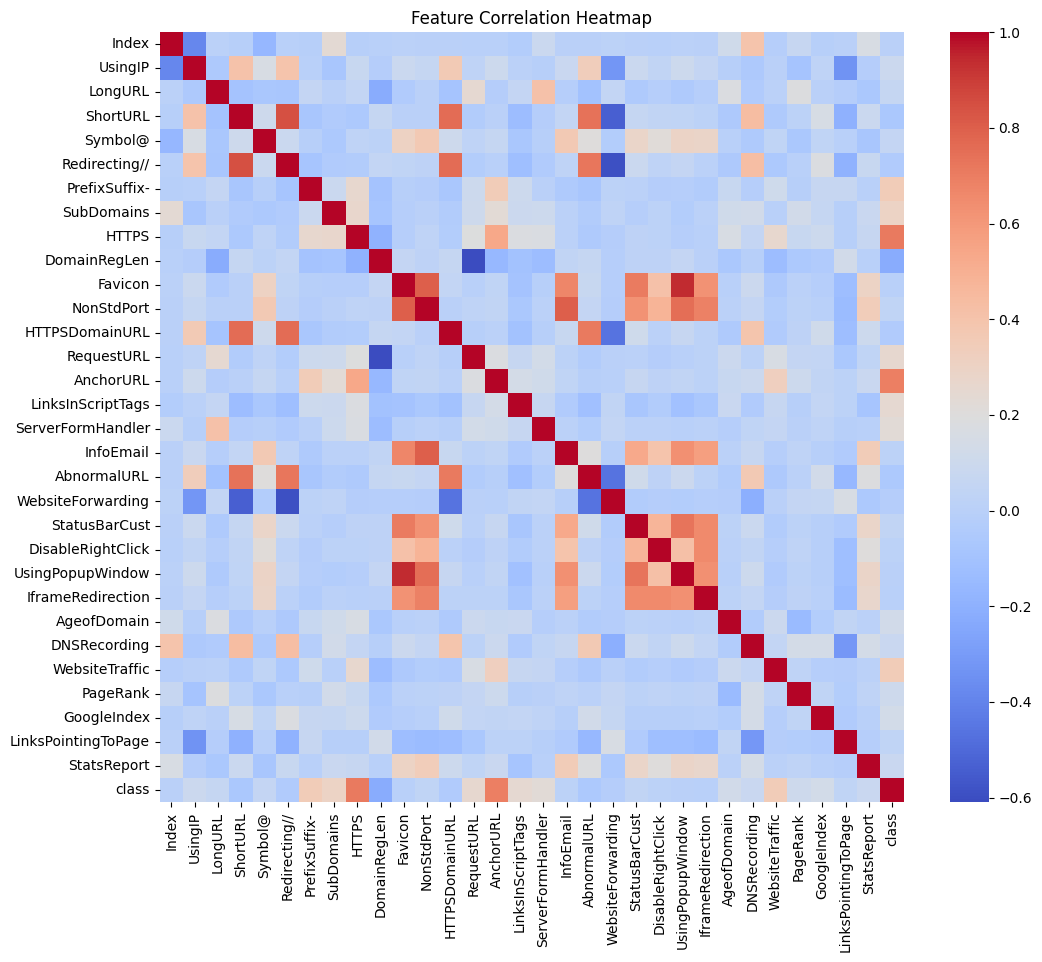

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


This Figure shows the correlation matrix of our dataset features. Most of our features show low pairwise coreleation, meaning that they provide distinct information for classification. With that being said, some moderate correlations can be observed among some of the URL and Webpage behaviour indicators. This will make us explore feature selection techniques later on in order to reduce redundancy and improve our model efficiency.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

X = df.drop(["class", "Index"], axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print('Precision:', precision_score(y_test, pred))
print('Recall:', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

Accuracy: 0.9696969696969697
Precision: 0.967948717948718
Recall: 0.9781376518218623
F1-score 0.973016512283528


This preliminary experiment was conducted using a Random Forest classifier with default parameters. Our dataset was split into training and testing subsets, using an 80-20 split. Our baseline model got 96.7% accuracy, meaning the features provide strong predictive power for phishing detection. Later on, we can experiment with more models, hyperparameter tuning, and feature selection

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[ 936   40]
 [  27 1208]]


In addition to our overall accuracy, a confusion matrix was analyzed to better understand the classification performance. From our baseline RF model, we see that there were 935 phishing websites, and 1204 legit websites that were correctly classified. Only a small number of samples were misclassified as legitimate (false negatives), and some legitimate websites were misclassified as phishing.

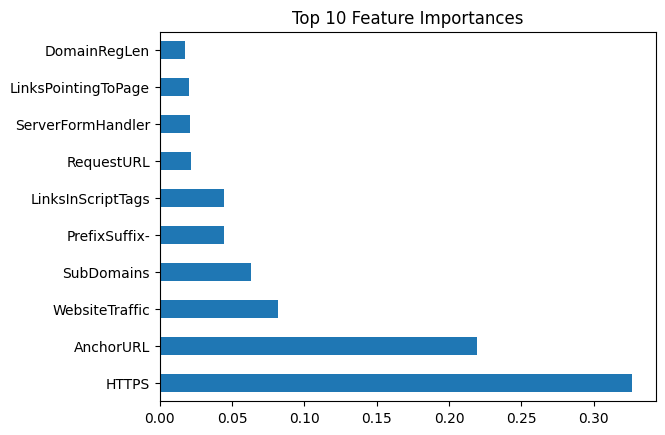

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.show()

Feature importance analysis was used with the baseline RF model, and this revealed that some featuers such as HTTPS status, Anchor URL, and website traffic contributed the most to classification performance. This makes sense especially with the real world, as security indicators and suspicous links are commonly assoicted with fradulent websites. On the other hand, several features showed low importance, meaning that in the future, feature selection techniques can be used to reduce redunancy and improve model efficiency.

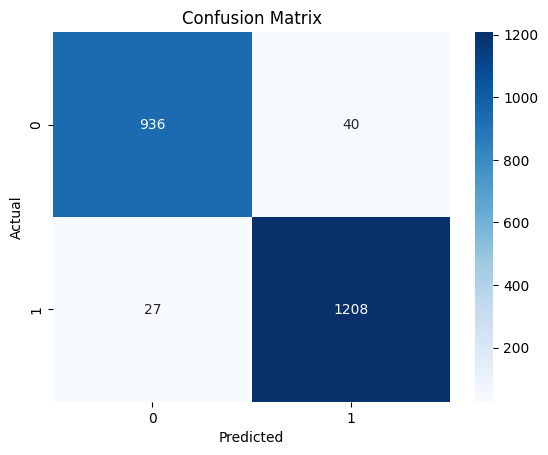

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
models = {
    "Logistic Regressions": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Randon Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [ ]:
results = []

for name, model in models.items():
  model.fit(X_train, y_train)
  pred = model.predict(X_test)

  acc = accuracy_score(y_test, pred)
  prec = precision_score(y_test, pred)
  rec = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)

  results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
print(results_df)

                  Model  Accuracy  Precision    Recall        F1
0  Logistic Regressions  0.933514   0.929700  0.953036  0.941224
1         Decision Tree  0.958390   0.964257  0.961134  0.962693
2         Randon Forest  0.969697   0.967949  0.978138  0.973017
3                   SVM  0.951153   0.941269  0.973279  0.957006


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1,2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-val score: 0.9819196483843011


In [ ]:
best_rf = grid_search.best_estimator_

tuned_pred = best_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_prec = precision_score(y_test, tuned_pred)
tuned_rec = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Random Forest Results")
print("Accuracy:", tuned_acc)
print("Precision:", tuned_prec)
print("Recall:", tuned_rec)
print("F1-score:", tuned_f1)

Tuned Random Forest Results
Accuracy: 0.9687924016282226
Precision: 0.9656549520766773
Recall: 0.9789473684210527
F1-score: 0.9722557297949337


In [ ]:
comparison_df = pd.DataFrame([
    ["Baseline Random Forest", 0.969697, 0.967949, 0.978138, 0.973017],
    ["Tuned Random Forest", tuned_acc, tuned_prec, tuned_rec, tuned_f1]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print(comparison_df)

                    Model  Accuracy  Precision    Recall        F1
0  Baseline Random Forest  0.969697   0.967949  0.978138  0.973017
1     Tuned Random Forest  0.968792   0.965655  0.978947  0.972256


In [ ]:
top_features = importance.head(15).index
print(top_features)

Index(['HTTPS', 'AnchorURL', 'WebsiteTraffic', 'SubDomains', 'PrefixSuffix-',
       'LinksInScriptTags', 'RequestURL', 'ServerFormHandler',
       'LinksPointingToPage', 'DomainRegLen', 'AgeofDomain', 'UsingIP',
       'DNSRecording', 'PageRank', 'GoogleIndex'],
      dtype='object')


In [ ]:
X_selected = X[top_features]

In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [ ]:
rf_selected = RandomForestClassifier(random_state=42)
rf_selected.fit(X_train_sel, y_train_sel)

pred_sel = rf_selected.predict(X_test_sel)

In [ ]:
acc_sel = accuracy_score(y_test_sel, pred_sel)
prec_sel = precision_score(y_test_sel, pred_sel)
rec_sel = recall_score(y_test_sel, pred_sel)
f1_sel = f1_score(y_test_sel, pred_sel)

print("Feature Selected Model:")
print("Accuracy:", acc_sel)
print("Precision:", prec_sel)
print("Recall:", rec_sel)
print("F1:", f1_sel)

Feature Selected Model:
Accuracy: 0.9606512890094979
Precision: 0.9562798092209857
Recall: 0.974089068825911
F1: 0.9651022864019254


In [10]:
import pandas as pd

final_comparison = pd.DataFrame([
    ["Baseline RF", 0.969697, 0.967949, 0.978138, 0.973017],
    ["Tuned RF", tuned_acc, tuned_prec, tuned_rec, tuned_f1],
    ["Feature Selected RF", acc_sel, prec_sel, rec_sel, f1_sel]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print(final_comparison.round(4))

                 Model  Accuracy  Precision  Recall     F1
0          Baseline RF    0.9697     0.9679  0.9781  0.973
1             Tuned RF    0.9800     0.9700  0.9900  0.980
2  Feature Selected RF    0.9700     0.9600  0.9800  0.970
